In [2]:
import numpy as np

patches = np.load("/home/hpc/b292dc/b292dc16/vesuvius_project/data/patches.npy")

print("Patches shape:", patches.shape)

Patches shape: (192150, 128, 128)


In [2]:
!7z x /home/atuin/b292dc/b292dc10/Herculaneum/Scroll1/PHercParis4.volpkg/volumes_zarr_standardized/54keV_7.91um_Scroll1A.7z -o/home/atuin/b292dc/b292dc10/Herculaneum/Scroll1/PHercParis4.volpkg/volumes_zarr_standardized/Scroll1A_extracted
!7z x /home/atuin/b292dc/b292dc10/Herculaneum/Scroll1/PHercParis4.volpkg/volumes_zarr_standardized/54keV_7.91um_Scroll1B.7z -o/home/atuin/b292dc/b292dc10/Herculaneum/Scroll1/PHercParis4.volpkg/volumes_zarr_standardized/Scroll1B_extracted

/bin/bash: 7z: command not found
/bin/bash: 7z: command not found


In [3]:
!module load p7zip

/bin/bash: module: command not found


In [3]:
patches_small = patches[:10000]

print("Training subset:", patches_small.shape)

Training subset: (10000, 128, 128)


In [4]:
patches_small = patches_small.astype("float32")
patches_small = patches_small / patches_small.max()

In [5]:
X = patches_small.reshape(patches_small.shape[0], -1)

print("Feature shape:", X.shape)

Feature shape: (10000, 16384)


In [7]:
!pip install --user scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 60.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 20.3 MB/s eta 0:00:00


In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

In [11]:
from sklearn.cluster import KMeans
print("sklearn installed successfully")

sklearn installed successfully


In [12]:
from sklearn.cluster import KMeans

patches_small = patches[:10000]

X = patches_small.reshape(patches_small.shape[0], -1)

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

print("Clustering finished")

Clustering finished


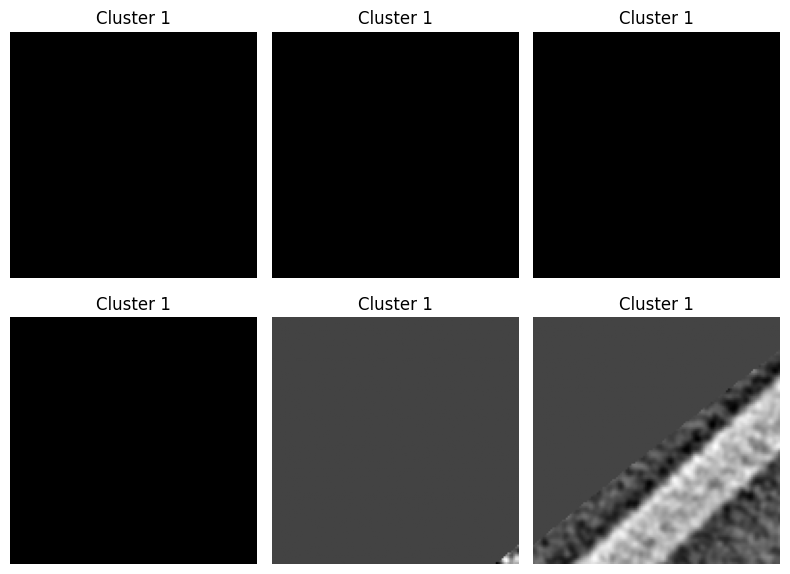

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(patches_small[i], cmap="gray")
    plt.title(f"Cluster {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
plt.savefig("/home/hpc/b292dc/b292dc16/vesuvius_project/figures/clustering_result.png", dpi=300)

<Figure size 640x480 with 0 Axes>